In [1]:
pip list

Package                 Version
----------------------- -----------
appnope                 0.1.4
asttokens               3.0.1
certifi                 2026.2.25
charset-normalizer      3.4.4
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.20
decorator               5.2.1
executing               2.2.1
fonttools               4.61.1
idna                    3.11
ipykernel               7.2.0
ipython                 9.10.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
joblib                  1.5.3
jupyter_client          8.8.0
jupyter_core            5.9.1
kiwisolver              1.4.9
matplotlib              3.10.8
matplotlib-inline       0.2.1
nest-asyncio            1.6.0
numpy                   2.4.2
packaging               26.0
pandas                  3.0.1
parso                   0.8.6
pexpect                 4.9.0
pillow                  12.1.1
pip                     26.0
platformdirs            

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
df = pd.read_csv('spotify_data.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1159764 entries, 0 to 1159763
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Unnamed: 0        1159764 non-null  int64  
 1   artist_name       1159749 non-null  str    
 2   track_name        1159763 non-null  str    
 3   track_id          1159764 non-null  str    
 4   popularity        1159764 non-null  int64  
 5   year              1159764 non-null  int64  
 6   genre             1159764 non-null  str    
 7   danceability      1159764 non-null  float64
 8   energy            1159764 non-null  float64
 9   key               1159764 non-null  int64  
 10  loudness          1159764 non-null  float64
 11  mode              1159764 non-null  int64  
 12  speechiness       1159764 non-null  float64
 13  acousticness      1159764 non-null  float64
 14  instrumentalness  1159764 non-null  float64
 15  liveness          1159764 non-null  float64
 16  valence    

In [ ]:
df = df.drop(columns=['artists','duration_ms','time_signature','mode','key'])

In [4]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)

ValueError: could not convert string to float: 'Jason Mraz'

In [5]:
scaled_features.shape

(100, 9)

In [6]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

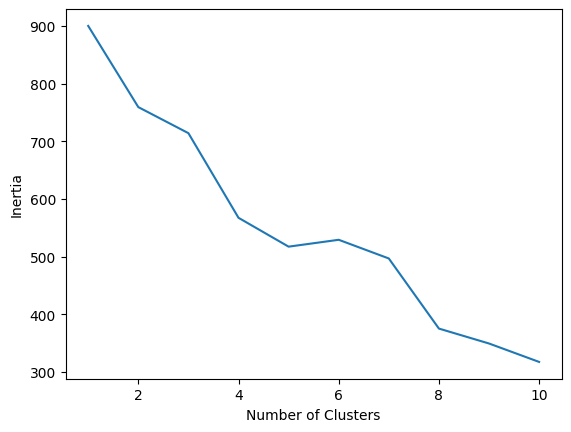

In [7]:
plt.plot(range(1, 11), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [8]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(scaled_features)
labels = kmeans.labels_
df['cluster'] = labels
print(df.head())

   danceability  energy  loudness  speechiness  acousticness  \
0         0.754   0.449    -9.211       0.1090        0.0332   
1         0.740   0.613    -4.880       0.1450        0.2580   
2         0.587   0.535    -6.090       0.0898        0.1170   
3         0.739   0.559    -8.011       0.1170        0.5800   
4         0.835   0.626    -5.833       0.1250        0.0589   

   instrumentalness  liveness  valence    tempo  cluster  
0          0.000083     0.552    0.357   77.169        2  
1          0.003720     0.123    0.473   75.023        1  
2          0.000066     0.131    0.140  159.847        3  
3          0.000000     0.112    0.439  140.124        0  
4          0.000060     0.396    0.350   91.030        2  


In [9]:
print(df['cluster'].value_counts())

cluster
1    34
2    30
3    29
0     7
Name: count, dtype: int64


In [10]:
centers = kmeans.cluster_centers_
print(centers)

[[-0.74950814 -1.60377281 -1.41135529 -0.52894462  2.60066423 -0.11811405
  -0.40299322 -0.20205074 -0.37613531]
 [ 0.09593042  0.79203513  0.87097445 -0.42112619 -0.2769989  -0.10614429
   0.17332533  0.86910085 -0.40078303]
 [ 0.95087552 -0.60339013 -0.54132678  0.62874113 -0.13641163 -0.07387914
  -0.14621974 -0.01824858  0.14865768]
 [-0.91521872  0.08272135 -0.12047727 -0.02901142 -0.16187373  0.22938202
   0.04532702 -0.95129712  0.40689102]]


In [11]:
centers_df = pd.DataFrame(centers, columns=df.drop("cluster", axis=1).columns)
print(centers_df)

   danceability    energy  loudness  speechiness  acousticness  \
0     -0.749508 -1.603773 -1.411355    -0.528945      2.600664   
1      0.095930  0.792035  0.870974    -0.421126     -0.276999   
2      0.950876 -0.603390 -0.541327     0.628741     -0.136412   
3     -0.915219  0.082721 -0.120477    -0.029011     -0.161874   

   instrumentalness  liveness   valence     tempo  
0         -0.118114 -0.402993 -0.202051 -0.376135  
1         -0.106144  0.173325  0.869101 -0.400783  
2         -0.073879 -0.146220 -0.018249  0.148658  
3          0.229382  0.045327 -0.951297  0.406891  


In [12]:
cluster_analysis = df.groupby("cluster").mean()
print(cluster_analysis)

         danceability    energy  loudness  speechiness  acousticness  \
cluster                                                                
0            0.618714  0.427571 -8.173857     0.060557      0.767429   
1            0.728971  0.773382 -4.137176     0.071771      0.134806   
2            0.840467  0.571967 -6.635067     0.180960      0.165713   
3            0.597103  0.671000 -5.890724     0.112552      0.160115   

         instrumentalness  liveness   valence       tempo  
cluster                                                    
0                0.000003  0.113529  0.443000  109.127286  
1                0.000163  0.177559  0.662706  108.421088  
2                0.000595  0.142057  0.480700  124.163467  
3                0.004653  0.163338  0.289321  131.562276  


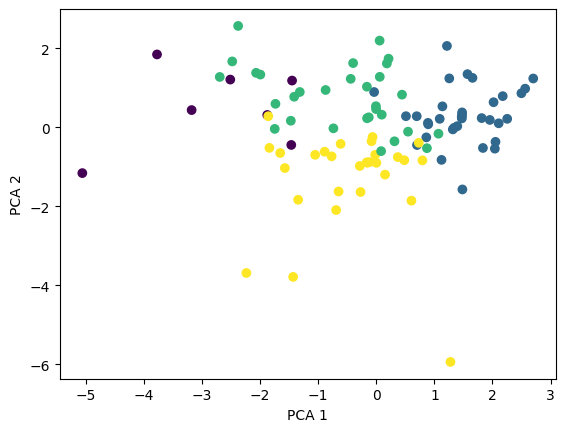

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_features)

plt.scatter(X_pca[:,0], X_pca[:,1], c = labels)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [14]:
songs_view = pd.read_csv('top2018.csv')[['name', 'artists']].copy()
songs_view['cluster'] = labels

cluster_0 = songs_view[songs_view['cluster'] == 0]
print(cluster_0[['name', 'artists']])
cluster_1 = songs_view[songs_view['cluster'] == 1]
print(cluster_1[['name', 'artists']])
cluster_2 = songs_view[songs_view['cluster'] == 2]
print(cluster_2[['name', 'artists']])
cluster_3 = songs_view[songs_view['cluster'] == 3]
print(cluster_3[['name', 'artists']])

                                   name        artists
3          Psycho (feat. Ty Dolla $ign)    Post Malone
38                              changes   XXXTENTACION
52                 Too Good At Goodbyes      Sam Smith
80                 lovely (with Khalid)  Billie Eilish
84  Perfect Duet (Ed Sheeran & Beyonc?)     Ed Sheeran
94   Everybody Dies In Their Nightmares   XXXTENTACION
99                           Be Alright     Dean Lewis
                                                 name            artists
1                                                SAD!       XXXTENTACION
6                                           I Like It            Cardi B
7                            One Kiss (with Dua Lipa)      Calvin Harris
9                                             FRIENDS         Marshmello
12                                      Nice For What              Drake
14                                         The Middle               Zedd
15                           All The Stars (with 

In [15]:
cluster_labels = {
    0: "energetic / workout",
    1: "dance / club",
    2: "acoustic / calm",
    3: "fast / eDM"
}

for cluster_num, label in cluster_labels.items():
    print("\n", label)
    print("-" * 30)

    songs = songs_view[songs_view["cluster"] == cluster_num]

    for _, row in songs.iterrows():
        print(row["name"], "-", row["artists"])


 energetic / workout
------------------------------
Psycho (feat. Ty Dolla $ign) - Post Malone
changes - XXXTENTACION
Too Good At Goodbyes - Sam Smith
lovely (with Khalid) - Billie Eilish
Perfect Duet (Ed Sheeran & Beyonc?) - Ed Sheeran
Everybody Dies In Their Nightmares - XXXTENTACION
Be Alright - Dean Lewis

 dance / club
------------------------------
SAD! - XXXTENTACION
I Like It - Cardi B
One Kiss (with Dua Lipa) - Calvin Harris
FRIENDS - Marshmello
Nice For What - Drake
The Middle - Zedd
All The Stars (with SZA) - Kendrick Lamar
X - Nicky Jam
These Days (feat. Jess Glynne, Macklemore & Dan Caplen) - Rudimental
Mine - Bazzi
New Rules - Dua Lipa
Shape of You - Ed Sheeran
Solo (feat. Demi Lovato) - Clean Bandit
?chame La Culpa - Luis Fonsi
Dura - Daddy Yankee
Me Niego - Reik
Jackie Chan - Ti?sto
Finesse (Remix) [feat. Cardi B] - Bruno Mars
Back To You - From 13 Reasons Why ? Season 2 Soundtrack - Selena Gomez
Happier - Marshmello
Believer - Imagine Dragons
Rise - Jonas Blue
Body (f

In [16]:
import pickle

with open('../models/kmeans_model.pkl','wb') as f:
    pickle.dump(kmeans, f)

In [17]:
with open("../models/kmeans_model.pkl", "rb") as f:
    model = pickle.load(f)

In [18]:
with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [19]:
with open("../models/scaler.pkl", "rb") as f:
    model = pickle.load(f)